In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# labeled Supervised Learning : Classification & Regression

지도학습에는 분류와 회귀가 있다

# *** Classification Algorithms ***

# ** SVM (Support Vector Machine) **

2개의 그룹을 분류하는 수많은 직선 중에서 가장 좋은 직선을 선택 (binary 분류)

Support Vector : Decision Boundary에 가장 가까운 데이터

### *Support Vector 사이의 거리(Margin)가 최대가 되도록 함

gamma : 한 점이 미치는 영향 범위.  클수록 overfitting

### *Kernel Trick : 저차원 데이터를 고차원 데이터로 mapping

고차원에서는 선형분류 (깔끔한 원 모양), 원래 차원에서는 입체적인 비선형 분류

## 데이터 읽어오기

In [27]:
diabetes = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/diabetes.csv')
print(diabetes.shape)
diabetes.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [28]:
diabetes['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


outcome : 1이면 diabetes

### EDA

In [29]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### ***bmi, insulin, skin thickness, blood pressure, glucose가 min값이 0인건 말이 안됨 -> 이건 결측치로 두자

(이 결측치 어떻게 처리할진 아직 모름)

### 데이터 시각화

<Axes: xlabel='BMI', ylabel='Glucose'>

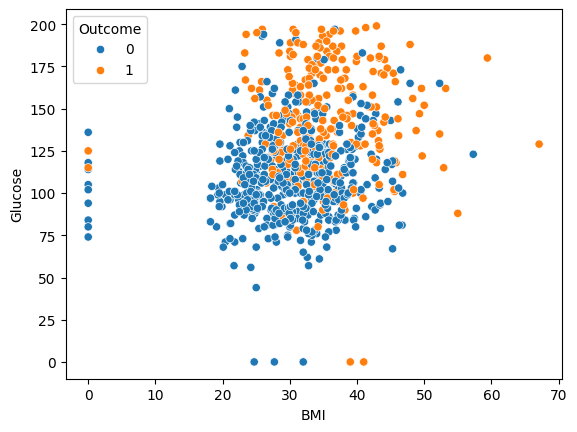

In [31]:
sns.scatterplot(x='BMI', y='Glucose', data=diabetes, hue='Outcome')

## Train, Validation, Test 데이터 나누기

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
train, test = train_test_split(diabetes, test_size=0.2, random_state=SEED, stratify=diabetes['Outcome'], shuffle=True)
x_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

## 데이터 전처리

encoding 필요없음 (문자 없으니까)

### ***0이었던 결측치 처리 -> NaN으로 replace하고, NaN값을 평균으로 채우자

In [34]:
temp_cols = ['BMI', 'Insulin', 'SkinThickness', 'BloodPressure', 'Glucose']

x_train[temp_cols] = x_train[temp_cols].replace(0, np.nan)

mean_values = {}
for col in temp_cols:
  u = x_train[col].mean()
  x_train[col] = x_train[col].fillna(u)
  mean_values[col] = u

### scaling

In [35]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)

In [38]:
y_train = y_train.to_numpy()

## 모델 학습

SVC : Support Vector Machine Classifier

In [39]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [41]:
clf = SVC(random_state=SEED)

param_grid = {
    'C' : [0.01, 0.1, 1.0, 10],
    'gamma' : ['scale', 'auto'],
    'kernel' : ['rbf', 'poly']
        }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_s, y_train)

best_model = grid_search.best_estimator_

## 학습 결과 확인

### confusion matrix

In [42]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred)     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred)    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred)       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

## Test

### 절차
1. x, y 분리 - 여기서도 결측치 처리 잊지 말기.
2. x,y scaling - 이때 scaling 방식 통일하기
3. 테스트

In [54]:
x_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

x_test[temp_cols] = x_test[temp_cols].replace(0, np.nan)
for col in temp_cols:
    x_test[col] = x_test[col].fillna(mean_values[col])

In [55]:
x_test_s = scaler.transform(x_test)
y_test = y_test.to_numpy()

1. Accuracy: 0.7403
2. Recall: 0.5370
3. Precision: 0.6591
4. F1 Score: 0.5918


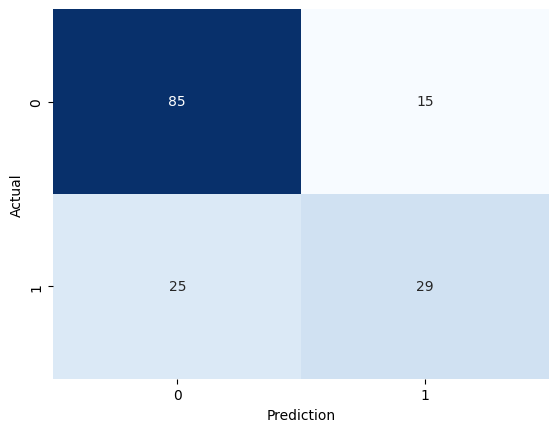

In [56]:
y_predict = best_model.predict(x_test_s)

print_metrics(y_test, y_predict)